# 1. Tokenizer

In this section, we are going to build a simple tokenizer that allows us to tokenize our sentences into smaller components called tokens and decode input tokens into the original string. Each token has its own unique identifier.

In the tokenizer, we have two main processes:
- **Encoding**: Chunking our sentences into smaller components called token. Each token will be represented with a unique identifier
<br>
<img height="200px" width="600px" src="images/tokenizer_encoding.png"/>
- **Decoder**: Converting token ids into the original sentence

In this notebook, we will build a tokenizer using an algorithm called **Byte Pair Encoding**, which is used in building many large language models such as ChatGPT or Gemini.

### Byte Pair Encoding

- Materials: [Byte Pair Encoding Hugging Face](https://www.youtube.com/watch?v=HEikzVL-lZU)

- Core ideas

    - **Rule 1**: Do not split frequently used words into smaller subwords

    -  **Rule 2**: Split the rare words into smaller, meaningful subwords

    Eg: "play" should not be split. "playing" should be split into "play" and "ing"

#### Benefits
1. "plays" and "playing" comes from the same root "play"
2. Some words have different root words but share the suffix part such as "classification" and "location" which both share "cation"



In [ ]:
from tokenizer import TokenizerV2 # You can inspect the implementation of it in tokenizer.py

In [ ]:
# Load dataset for training tokenizer
urls = {
    "Education and the good life": "https://www.gutenberg.org/cache/epub/70302/pg70302.txt",
    "What Is and What Might Be": "https://www.gutenberg.org/cache/epub/20555/pg20555.txt",
    "How we think": "https://www.gutenberg.org/cache/epub/37423/pg37423.txt",
    "The Reform of Education": "https://www.gutenberg.org/cache/epub/36762/pg36762.txt",
}

In [ ]:
import asyncio
import httpx
async def fetch_data(name, url):
    async with httpx.AsyncClient() as client:
        response = await client.get(url)
        text = response.text
        with open(f"dataset/{name}.txt", mode = 'w') as f:
            f.write(text)

tasks = [fetch_data(name, url) for name, url in urls.items()]

results = await asyncio.gather(*tasks)

In [113]:
def load_text_data(data_path):
    with open(data_path, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
        text = ''.join(lines)
        return text

names = list(urls.keys())
data_paths = [f"dataset/{name}.txt" for name in names]
text = "\n".join([load_text_data(data_path) for data_path in data_paths])

In [ ]:
# DEFINE ALL CONSTANTS
VOCAB_SIZE = 2000
BATCH_SIZE = 16
CONTEXT_SIZE = 512
D_MODEL = 256
NUM_HEADS = 4
HIDDEN_DIM = D_MODEL * 4
N_LAYERS = 3
DROPOUT_RATE = 0.3
EPOCHS = 5
LR = 1e-5

In [47]:
tokenizer = TokenizerV2()

In [ ]:
# Train tokenizer on our text data
tokenizer = TokenizerV2()
tokenizer.train(text, vocab_size=VOCAB_SIZE, allowed_special={"<|start|>", "<|endoftext|>"})

In [294]:
tokenizer.save_vocab_and_merges(
    vocab_path="vocab.json", bpe_merges_path="bpe_merges.txt"
)

In [50]:
tokenizer.load_vocab_and_merges(
    vocab_path="vocab.json", bpe_merges_path="bpe_merges.txt"
)

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

# 2. Create input-target pair dataset for training

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset

class EducationDataset(Dataset):
    def __init__(self, data_path, tokenizer: TokenizerV2, context_size ):
        """Construct input-target pair dataset to train GPT.
            The goal is to construct dataset that allows next word prediction within the context size
            Example: Sentence: "my name is khai"
                    Input ['my', 'name', 'is']
                    Output ['name', 'is', 'khai']
        Args:
            data_path (string): Data path to your txt file
            tokenizer (TokenizerV2): Your pretrained tokenizer
            context_size (int): Context size that you want to train for your model
        """

        text = load_text_data(data_path)
        self.context_size = context_size
        self.tokenizer = tokenizer
        self.X = []
        self.y = []
        # Append special token before and after text
        text = "<|start|>" + text + "<|endoftext|>"
        tokens = tokenizer.encode(text, allowed_special={"<|start|>", "<|endoftext|>"})
        if len(tokens) <= context_size:
            self.X.append(tokens[:len(tokens)])
            self.y.append(tokens[1:])
        else:
            for i in range(len(tokens) - context_size):
                self.X.append(tokens[i : i + context_size])
                self.y.append(tokens[i+1 : i + context_size + 1])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        x, y = self.X[index], self.y[index]
        return torch.tensor(x), torch.tensor(y)

In [77]:
datasets = [EducationDataset(data_path, tokenizer, CONTEXT_SIZE) for data_path in data_paths]

In [114]:
dataset = ConcatDataset(datasets)

# Split into training and val dataset
train_ratio = 0.8
val_ratio = 1 - train_ratio
train_size = int(len(dataset) * train_ratio)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Number of train batches: ", len(train_loader))
print("Number of val batches: ", len(val_loader))

Number of train batches:  51189
Number of val batches:  12798


# 3. Training model


In [ ]:
from gpt import MiniGPT
import torch
import torch.nn as nn

In [116]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [243]:
model = MiniGPT(
    N_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    vocab_size=VOCAB_SIZE,
    dropout_rate=DROPOUT_RATE,
    context_size=CONTEXT_SIZE,
)

model = model.to(device)

In [118]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


total_params, trainable_params = count_parameters(model)

# Convert to MB (float32 = 4 bytes)
model_size_mb = total_params * 4 / (1024**2)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {model_size_mb:.2f} MB")

Total parameters: 3,395,792
Trainable parameters: 3,395,792
Model size: 12.95 MB


In [119]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)
criterion = nn.CrossEntropyLoss()

def perplexity(cross_entropy_loss):
    return torch.exp(cross_entropy_loss).item()

def train_step(data_loader, model, optimizer):
    model.train()
    total_loss = 0
    total_perplexity = 0
    for inputs, labels in tqdm(data_loader, desc='Train'):
        inputs = inputs.to(device = device)
        labels = labels.to(device = device)

        B, N = inputs.shape[0], inputs.shape[1]
        raw_logits = model(inputs)
        raw_logits = raw_logits.reshape(B * N, VOCAB_SIZE)
        labels = labels.reshape((B * N,))
        loss = criterion(raw_logits, labels)

        total_loss += loss.item()
        # Add perplexity metric or BLEU here
        total_perplexity += perplexity(loss)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return total_loss / len(data_loader), total_perplexity / len(data_loader)


def eval_step(data_loader, model):
    model.eval()
    total_perplexity = 0
    with torch.inference_mode():
        total_loss = 0
        for inputs, labels in tqdm(data_loader, desc="Eval"):
            inputs = inputs.to(device=device)
            labels = labels.to(device=device)

            B, N = inputs.shape[0], inputs.shape[1]
            raw_logits = model(inputs)
            raw_logits = raw_logits.reshape(B * N, VOCAB_SIZE)
            labels = labels.reshape((B * N,))
            loss = criterion(raw_logits, labels)
            total_loss += loss.item()
            total_perplexity += perplexity(loss)
            # Add perplexity metric or BLEU here
        return total_loss / len(data_loader), total_perplexity / len(data_loader)

In [ ]:
train_losses = []
train_perplexities = []
val_losses = []
val_perplexities = []

# Add tracking
best_perplexity = float('inf')
best_epoch = None
MODEL_SAVED_PATH = "best_gpt.pth"

for epoch in range(EPOCHS):
    train_loss, train_perplexity = train_step(train_loader, model, optimizer)
    val_loss, val_perplexity = eval_step(val_loader, model)
    train_losses.append(train_loss)
    train_perplexities.append(train_perplexity)
    val_losses.append(val_loss)
    val_perplexities.append(val_perplexity)

    if val_perplexity < best_perplexity:
        best_perplexity = val_perplexity
        best_epoch = epoch + 1
        torch.save(model.state_dict(), MODEL_SAVED_PATH)

    # Logging model performance
    print(
        f"""
    Epoch: [{epoch+1}|{EPOCHS}]:     
    Train loss = {train_loss} - Train perplexity = {train_perplexity}
    Validation loss = {val_loss} - Validation perplexity = {val_perplexity}
            """
    )

print(f"Epoch = {best_epoch}: Best model perplexity = {best_perplexity}")

Eval: 100%|██████████| 12798/12798 [08:59<00:00, 23.72it/s]



    Epoch: [1|5]:     
    Train loss = 2.83937698809358 - Train perplexity = 21.88984400949987
    Validation loss = 2.3352823036129466 - Validation perplexity = 10.341892560844702
            


Eval: 100%|██████████| 12798/12798 [08:51<00:00, 24.10it/s]



    Epoch: [2|5]:     
    Train loss = 2.220848078586969 - Train perplexity = 9.267674773918113
    Validation loss = 1.984744035158144 - Validation perplexity = 7.28430257262355
            


Eval: 100%|██████████| 12798/12798 [08:52<00:00, 24.02it/s]



    Epoch: [3|5]:     
    Train loss = 1.9949642209011476 - Train perplexity = 7.365727219351238
    Validation loss = 1.8253677425244428 - Validation perplexity = 6.211844782621381
            


Eval: 100%|██████████| 12798/12798 [09:02<00:00, 23.58it/s]



    Epoch: [4|5]:     
    Train loss = 1.8760831711075177 - Train perplexity = 6.537149861352205
    Validation loss = 1.7188428720471858 - Validation perplexity = 5.58521582067227
            


Eval: 100%|██████████| 12798/12798 [09:16<00:00, 23.00it/s]


    Epoch: [5|5]:     
    Train loss = 1.7948480992237181 - Train perplexity = 6.026912286073903
    Validation loss = 1.639253235977317 - Validation perplexity = 5.159041447683431
            
Epoch = 4: Best model perplexity = 5.159041447683431


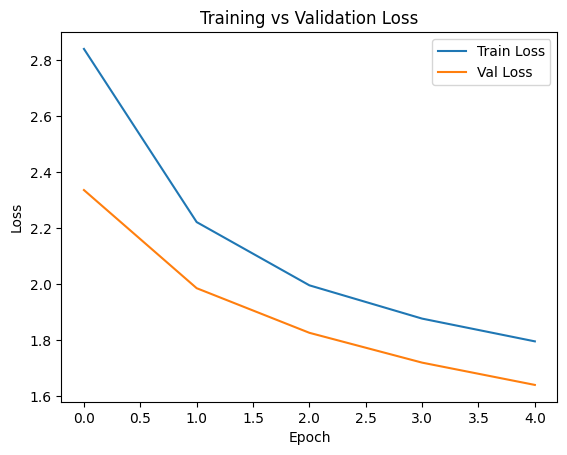

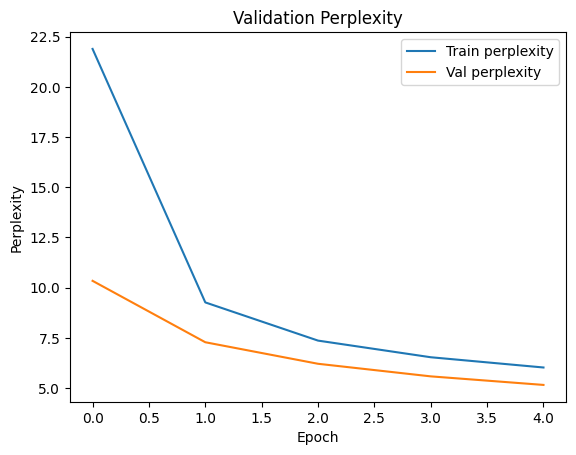

In [121]:
# Plot model Performance
import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_perplexities, label="Train perplexity")
plt.plot(val_perplexities, label="Val perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity")
plt.legend()
plt.show()

In [245]:
MODEL_SAVED_PATH = "best_gpt.pth"

# Train for 3 more epochs with larger learning rate
NEW_LR = 1e-3
new_optimizer = torch.optim.Adam(model.parameters(), lr=NEW_LR)
for epoch in range(EPOCHS, EPOCHS + 3, 1):
    train_loss, train_perplexity = train_step(train_loader, model, new_optimizer)
    val_loss, val_perplexity = eval_step(val_loader, model)
    train_losses.append(train_loss)
    train_perplexities.append(train_perplexity)
    val_losses.append(val_loss)
    val_perplexities.append(val_perplexity)

    if val_perplexity < best_perplexity:
        best_perplexity = val_perplexity
        best_epoch = epoch + 1
        torch.save(model.state_dict(), MODEL_SAVED_PATH)

    # Logging model performance
    print(
        f"""
    Epoch: [{epoch+1}|{EPOCHS + 3}]:     
    Train loss = {train_loss} - Train perplexity = {train_perplexity}
    Validation loss = {val_loss} - Validation perplexity = {val_perplexity}
            """
    )

print(f"Epoch = {best_epoch}: Best model perplexity = {best_perplexity}")

Eval: 100%|██████████| 12798/12798 [08:50<00:00, 24.13it/s]



    Epoch: [6|5]:     
    Train loss = 1.369442494106194 - Train perplexity = 4.02801081746221
    Validation loss = 0.8421418844097982 - Validation perplexity = 2.324039924692448
            


Eval: 100%|██████████| 12798/12798 [33:32<00:00,  6.36it/s]  



    Epoch: [7|5]:     
    Train loss = 1.1128983676669937 - Train perplexity = 3.048679230163748
    Validation loss = 0.6911987680572144 - Validation perplexity = 1.9977735926311713
            


Eval: 100%|██████████| 12798/12798 [09:06<00:00, 23.40it/s]


    Epoch: [8|5]:     
    Train loss = 1.0427898063720962 - Train perplexity = 2.8409157236200557
    Validation loss = 0.6280255177991058 - Validation perplexity = 1.8752094190052513
            
Epoch = 8: Best model perplexity = 1.8752094190052513


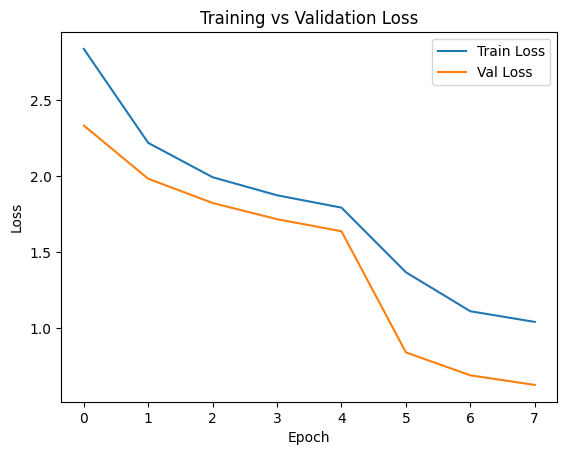

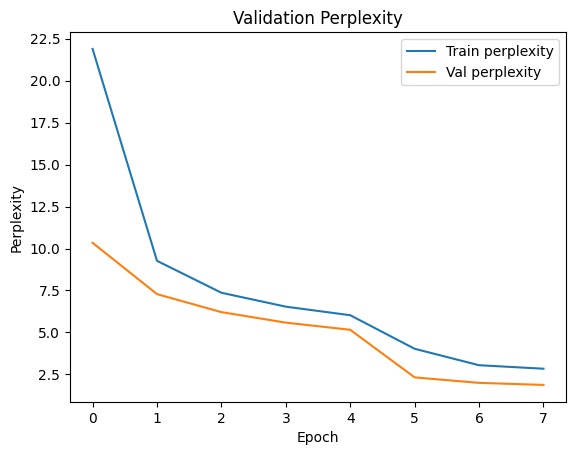

In [246]:
# Plot model Performance
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_perplexities, label="Train perplexity")
plt.plot(val_perplexities, label="Val perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity")
plt.legend()
plt.show()

In [244]:
# Load best weight again
state_dict = torch.load(MODEL_SAVED_PATH, map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

# 4. Evaluation

In [ ]:
def softmax_with_temperature(logits, temp = 0.1):
    """Softmax function with temperature for controlling model 
        behaviors

    Args:
        z (tensor): raw logits with shape: B x N x C
        temp (float): temperature
    """
    assert temp > 0, "temp must be greater than 0"

    logits = logits / temp
    return torch.softmax(logits, dim=-1)


def top_k_sampling(logits, k, temperature):
    """logits: (vocab_size,)"""
    logits = logits / temperature

    # Only keep top-k logits
    values, indices = torch.topk(logits, k)
    mask = torch.full_like(logits, float("-inf"))
    mask.scatter_(0, indices, values)

    probs = torch.softmax(mask, dim=-1)

    # Sample from top-k
    return torch.multinomial(probs, num_samples=1).item()


def top_p_sampling(logits, p, temperature):
    logits = logits / temperature

    # Sort by probability
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    probs = torch.softmax(sorted_logits, dim=-1)
    cumulative = torch.cumsum(probs, dim=-1)

    # Keep tokens until cumulative prob exceeds p
    mask = cumulative <= p
    mask[0] = True 
    filtered_logits = sorted_logits.clone()
    filtered_logits[~mask] = float("-inf")

    final_probs = torch.softmax(filtered_logits, dim=-1)
    sampled_idx = torch.multinomial(final_probs, num_samples=1)

    # Map back to original vocab index
    return sorted_indices[sampled_idx].item()


def generate(
    text, model, tokenizer, temperature=1.0, max_length=50, top_k=None, top_p=None
):
    tokens = tokenizer.encode(text)
    outputs = []
    model.eval()
    with torch.inference_mode():
        for _ in range(max_length):
            # Keep only context
            input_ids = torch.tensor([tokens], device=device)

            logits = model(input_ids)[0, -1]  

            if top_k is not None:
                next_id = top_k_sampling(logits, top_k, temperature)
            elif top_p is not None:
                next_id = top_p_sampling(logits, top_p, temperature)
            else:
                probs = softmax_with_temperature(logits, temperature)
                next_id = torch.multinomial(probs, num_samples=1).item()
                
            tokens.append(next_id)
            outputs.append(next_id)
            

        generated_text = tokenizer.decode(outputs)
    return generated_text

In [279]:
# Test with low temperature
text = "Education is"
output = generate(text, model, tokenizer, temperature=1, max_length=100)
print("Input: ", text)
print("Output: ", output)

Input:  Education is
Output:   the difficult result of an attitude and classification of the 
 alphabet and always say "the number of the difficult commonplace." The modern 
 elaboration of industry be kept apar


In [286]:
# Test with higher temperature
text = "We must learn a new language "
output = generate(text, model, tokenizer, temperature=2, max_length=100)
print("Input: ", text)
print("Output: ", output)

Input:  We must learn a new language 
Output:  --or 
 thexamination  that tributes under passions the 
 fact of which his thinking 
 the heart that we blchurch what answer exist seisation in the children's 
 drawings what theming arpropediibe their. Only how is th


In [282]:
text = "Education is"
output = generate(text, model, tokenizer, temperature=2, max_length=100)
print("Input: ", text)
print("Output: ", output)

Input:  Education is
Output:  ," simply G--thly fathfulness will by 
 of introduce find tidse. The pestories of official optowhere, the 
 analyses are actual elements, we see truthful. 
 
 sionaria must be 


In [283]:
text = "The teacher must "
output = generate(text, model, tokenizer, temperature=1, top_k=10)
print("Input: ", text)
print("Output: ", output)

Input:  The teacher must 
Output:   indeed learn to be 
 doing. But in point of fact as the teachers are interested in the


In [284]:
text = "Knowledge differs from"
output = generate(text, model, tokenizer, temperature=1, max_length=100, top_p=0.7)
print("Input: ", text)
print("Output: ", output)

Input:  Knowledge differs from
Output:   persons in old days and spell 
 of various kinds and compassions, and so on. There is no question whether 
 any trait or social cal scheme of education should be pretense. 
 But th
